<h1 style="text-align:center;">Preprocessing Lending Club Loan Data</h1>

<h4>Libraries Used</h4>

In [13]:
import numpy as np # linear algebra 
import pandas as pd # data processing 
import matplotlib.pyplot as plt # data visualisation 
import seaborn as sns # more data visualisation
from sklearn.impute import SimpleImputer, KNNImputer # Imputation Methods for missing values

In [14]:
import os
print(os.getcwd())

C:\Users\Admin\Desktop\Credit_Risk_Platform\notebooks


<h2 style="text-align:center;">Preliminary Investigation</h2>

<h4>Understanding the Data</h4>

In [15]:
data = pd.read_csv(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\data\lending_club_loan_data_raw.csv")
data.head(5)#display

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [16]:
data.shape

(396030, 27)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

<h4>From the data above, we can say:</h4>
<ul>
    <li>The dataset contains 396,030 loan records and 27 columns</li>
    <li> The dataset contains both numerical variables (stored as float64) and it also contains categorical variables (stored as str).</li>
    <li>Some columns contain missing values (e.g, emp_title, emp_length, title, revol_util, mort_acc, and pub_rec_banckruptcies), because the non-null count for these columns is lower than the total number of records.</li>
</ul>

In [18]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_amnt,396030.0,NaN,NaN,NaN,14113.888089,8357.441341,500.0,8000.0,12000.0,20000.0,40000.0
term,396030,2,36 months,302005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_rate,396030.0,NaN,NaN,NaN,13.6394,4.472157,5.32,10.49,13.33,16.49,30.99
installment,396030.0,NaN,NaN,NaN,431.849698,250.72779,16.08,250.33,375.43,567.3,1533.81
grade,396030,7,B,116018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_grade,396030,35,B3,26655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
emp_title,373103,173105,Teacher,4389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
emp_length,377729,11,10+ years,126041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_ownership,396030,6,MORTGAGE,198348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_inc,396030.0,NaN,NaN,NaN,74203.175798,61637.621158,0.0,45000.0,64000.0,90000.0,8706582.0


<h4>From the descriptive stats table, we can say:</h4>
<ul>
    <li>Some variables are stored as numerical values but represent counts rather than continuous data (e.g, pub_rec, pub_rec_bankruptcies, mort_acc, open_acc, and total_acc).</li>
    <li>Some categorical variables have a very large number of unique values ( e.g, address). They have to be simplified during feature engineering, as having too many unique categories can make model training less effective</li>

In [19]:
data.isnull().sum()/data.shape[0]*100

loan_amnt               0.000000
term                    0.000000
int_rate                0.000000
installment             0.000000
grade                   0.000000
sub_grade               0.000000
emp_title               5.789208
emp_length              4.621115
home_ownership          0.000000
annual_inc              0.000000
verification_status     0.000000
issue_d                 0.000000
loan_status             0.000000
purpose                 0.000000
title                   0.443401
dti                     0.000000
earliest_cr_line        0.000000
open_acc                0.000000
pub_rec                 0.000000
revol_bal               0.000000
revol_util              0.069692
total_acc               0.000000
initial_list_status     0.000000
application_type        0.000000
mort_acc                9.543469
pub_rec_bankruptcies    0.135091
address                 0.000000
dtype: float64

<h4>Treating missing Values</h4>
<p>From the missing value analysis above, we can clearly observe that most variables contain little to no missing data. However,<b> 6 variables contain missing values</b> (e.g, mort_acc (9.54%), pub_rec_banckruptcies (0.13%), revol_util (0.07%), title (0.44%), emp_length (4.62%), and emp_title (5.79%)). THEREFORE;</p>
<ol>
    <li><b>Columns with less than 1% missing values (pub_rec_banckruptcies, revol_util, and title) will have their missing records dropped</b>, because the portion of missing data is negligible (unlikely to significantly affect the analysis).</li>
    <li><b>Columns with higher percentages of missing values (emp_title, emp_length, and mort_acc) will be imputed rather than dropped</b> to avoid losing a large number of observations from the dataset.</li>
    <li><b>Special attention will be given to mort_acc, because it has the highest percentage of missing values</b> and requires a more informed imputation strategy based on its relationships with other variables. </li>
</ol>

<h2 style="text-align:center;">Data Cleaning</h2>

<p><b>emp_title</b> contains 173,105 unique values. Since a large portion of job titles are rarely repeated, the variable is unlikely to provide meaningful predictive value and would increase model complexity. Therefore, it is dropped from the dataset</p>

In [20]:
data = data.drop('emp_title', axis = 1)

<p><b>emp_length</b></p>

In [21]:
sorted(data['emp_length'].dropna().unique())# check employment Length categories

['1 year',
 '10+ years',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '< 1 year']

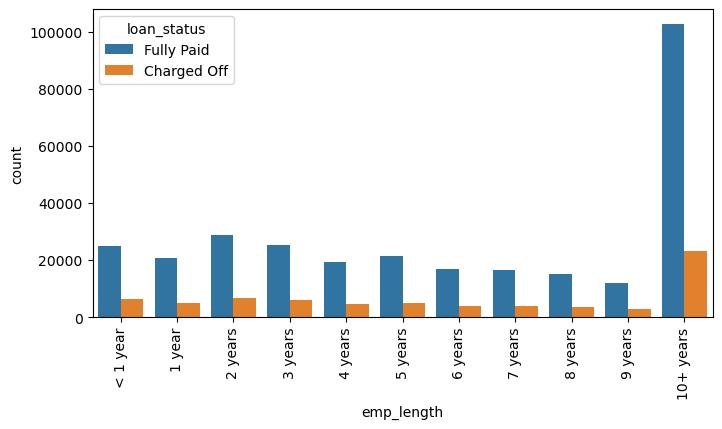

In [22]:
#create the correct order for the categories 
emp_length_order = [ '< 1 year','1 year','2 years','3 years','4 years','5 years','6 years','7 years','8 years','9 years','10+ years']
# Create Count plot 
plt.figure(figsize = (8,4), dpi = 100)
sns.countplot(x='emp_length',data=data,order=emp_length_order, hue = 'loan_status')
plt.xticks(rotation = 90)
plt.show()

<p>The <b>emp_length</b> variable contains 11 employment categories, with most borrowers having 10+ years of employment. However, the count plot only shows the number of borrowers in each category, not whether employment length affects loan default.</p>
<p>If the percentage of charged-off loans is similar across all employment groups, then emp_length is unlikely to be a useful predictor and can be dropped from the model.</p>

In [23]:
#count charged-off loans 
emp_co = data[data['loan_status']=="Charged Off"].groupby("emp_length").count()['loan_status']
#count fully paid loans
emp_fp = data[data['loan_status']=="Fully Paid"].groupby("emp_length").count()['loan_status']
# calculate the charge-off rate 
emp_len = emp_co/(emp_fp+emp_co) * 100
pd.DataFrame(emp_len.round())

,loan_status
emp_length,
1 year,20.0
10+ years,18.0
2 years,19.0
3 years,20.0
4 years,19.0
5 years,19.0
6 years,19.0
7 years,19.0
8 years,20.0


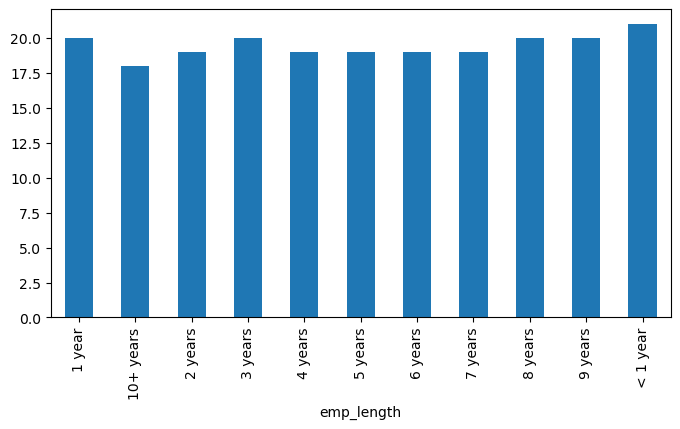

In [24]:
#Dispaly charge-off rate for each employment-length category 
plt.figure(figsize = (8,4), dpi = 100)
emp_len.round().plot(kind = 'bar')
plt.xticks(rotation = 90)
plt.show()

<p>Since the charge-off rates are very similar across all employment-length categories, this indicates that employment length has little influence on whether a borrower defaults on a loan.</p>
<p>Therefore, emp_length can be safely removed from the model. </p>

In [25]:
data = data.drop('emp_length',axis=1)

<p><b>pub_rec_banckruptcies, revol_util, title</b></p>
<p>Columns with less than 1% missing values (pub_rec_banckruptcies (0.13%), revol_util(0.07%), and title (0.44%)) will have their missing records dropped because the portion of missing data is negligible (unlikely to significantly affect the analysis).</p>

In [26]:
#DROPPING VALUES IN pub_rec_banckruptcies, revol_util, and title
data = data.dropna(subset=['title','revol_util','pub_rec_bankruptcies'])

In [27]:
data.isnull().sum()/data.shape[0]*100

loan_amnt               0.000000
term                    0.000000
int_rate                0.000000
installment             0.000000
grade                   0.000000
sub_grade               0.000000
home_ownership          0.000000
annual_inc              0.000000
verification_status     0.000000
issue_d                 0.000000
loan_status             0.000000
purpose                 0.000000
title                   0.000000
dti                     0.000000
earliest_cr_line        0.000000
open_acc                0.000000
pub_rec                 0.000000
revol_bal               0.000000
revol_util              0.000000
total_acc               0.000000
initial_list_status     0.000000
application_type        0.000000
mort_acc                9.453216
pub_rec_bankruptcies    0.000000
address                 0.000000
dtype: float64

<p><b>title</b></p>

In [28]:
# Review title column vs the purpose column 
data ['purpose'].head(10)

0              vacation
1    debt_consolidation
2           credit_card
3           credit_card
4           credit_card
5    debt_consolidation
6      home_improvement
7           credit_card
8    debt_consolidation
9    debt_consolidation
Name: purpose, dtype: object

In [29]:
data['title'].head(10)

0                   Vacation
1         Debt consolidation
2    Credit card refinancing
3    Credit card refinancing
4      Credit Card Refinance
5         Debt consolidation
6           Home improvement
7       No More Credit Cards
8         Debt consolidation
9         Debt Consolidation
Name: title, dtype: object

<p>Since the title column is simply a subcategory/description of the purose column, we can safely drop it and only retain "purpose"</p>

In [30]:
data = data.drop('title', axis = 1)

<p><b>mort_acc</b></p>

In [31]:
#IMPUTE/REPLACE missing values with the median value in each column (mort_acc)
si_median = SimpleImputer(missing_values=np.nan, strategy='median')
cols_median = ['mort_acc']
data[cols_median] = si_median.fit_transform(data[cols_median])

<p>Missing values in mort_acc were imputed using the median value of the column to preserve observations and reduce the impact of outliers.</p>

In [32]:
data.isnull().sum()

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
sub_grade               0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
address                 0
dtype: int64

<h4>ALL MISSING VALUES in the data set have been successfully addressed</h4>
<p>Every variable now contains zero missing values, indicating that the dataset is complete and ready for subsequent stages of analysis, feature engineering, and predictive model development.</p>

<h4>Checking for Dublicates</h4>

In [33]:
data[data.duplicated()]

,loan_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,issue_d,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address


<p>NO DUPLICATED RECORDS found in the dataset</p>

In [34]:
#INCLUDE CLEAN dataset shape 
# previous shape before cleaning: (396030, 27)
data.shape

(393464, 24)

In [35]:
data.head(1)

,loan_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,issue_d,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,RENT,117000.0,Not Verified,Jan-2015,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"


In [36]:
#save cleaned dataset
data.to_csv(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\data\lending_club_loan_data_cleaned.csv", index=False)